## Machine Learning Pipeline

As the class practice, the students will be required to develop a machine learning pipeline using the `Churn_Modelling_train_test.csv` dataset.

**About dataset**

This dataset is obained from [kaggle](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction?resource=download). It contains information on bank customers who either left the bank or continue to be a customer. The dataset includes the following attributes:

* Customer ID: A unique identifier for each customer
* Surname: The customer's surname or last name
* Credit Score: A numerical value representing the customer's credit score
* Geography: The country where the customer resides (France, Spain or Germany)
* Gender: The customer's gender (Male or Female)
* Age: The customer's age.
* Tenure: The number of years the customer has been with the bank
* Balance: The customer's account balance
* NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)
* HasCrCard: Whether the customer has a credit card (1 = yes, 0 = no)
* IsActiveMember: Whether the customer is an active member (1 = yes, 0 = no)
* EstimatedSalary: The estimated salary of the customer
* Exited: Whether the customer has churned (1 = yes, 0 = no)


### Exploratory Data Analysis

In this section the students are required to do an EDA to understand the dataset.

In [49]:
# import packages

import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score

In [56]:
# Load the dataset

df = pd.read_csv("Churn_Modelling_train_test.csv")

In [57]:
# dataset analysis

print(df.info())

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9001 non-null   int64  
 1   CustomerId       9001 non-null   int64  
 2   Surname          9001 non-null   object 
 3   CreditScore      9001 non-null   int64  
 4   Geography        9000 non-null   object 
 5   Gender           9001 non-null   object 
 6   Age              9000 non-null   float64
 7   Tenure           9001 non-null   int64  
 8   Balance          9001 non-null   float64
 9   NumOfProducts    9001 non-null   int64  
 10  HasCrCard        9000 non-null   float64
 11  IsActiveMember   9001 non-null   float64
 12  EstimatedSalary  9001 non-null   float64
 13  Exited           9001 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 984.6+ KB
None


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,4784,15729224,Jennings,710,France,Female,37.0,5,0.00,2,1.0,0.0,115403.31,0
1,1497,15799156,Okwuadigbo,569,Spain,Male,38.0,8,0.00,2,0.0,0.0,79618.79,0
2,1958,15674922,Beavers,710,France,Male,54.0,6,171137.62,1,1.0,1.0,167023.95,1
3,9174,15653572,Thornton,673,Spain,Male,43.0,8,127132.96,1,0.0,1.0,6009.27,1
4,9748,15775761,Iweobiegbunam,610,Germany,Female,69.0,5,86038.21,3,0.0,0.0,192743.06,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Surname    9001 non-null   object
 1   Geography  9000 non-null   object
 2   Gender     9001 non-null   object
dtypes: object(3)
memory usage: 211.1+ KB


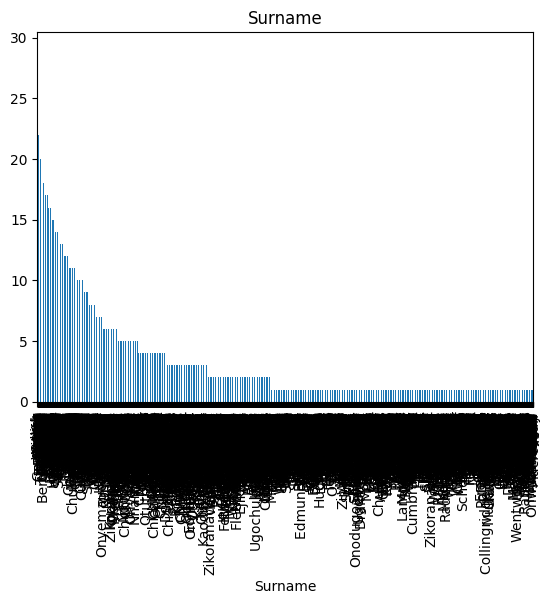

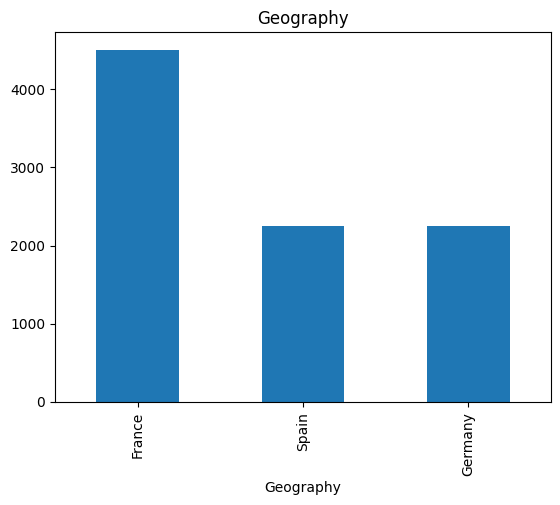

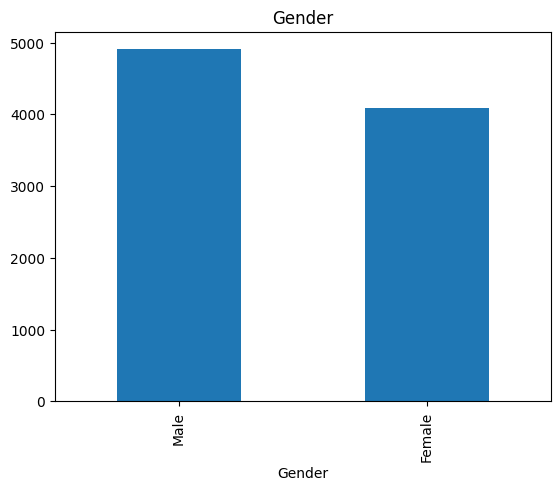

In [58]:
# review categorical variables

import matplotlib.pyplot as plt

categorical_df =df.select_dtypes(include=["object"])
categorical_df.info()

for col in categorical_df.columns:
    plt.figure()
    categorical_df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   HasCrCard       9000 non-null   float64
 1   IsActiveMember  9001 non-null   float64
 2   Exited          9001 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 211.1 KB


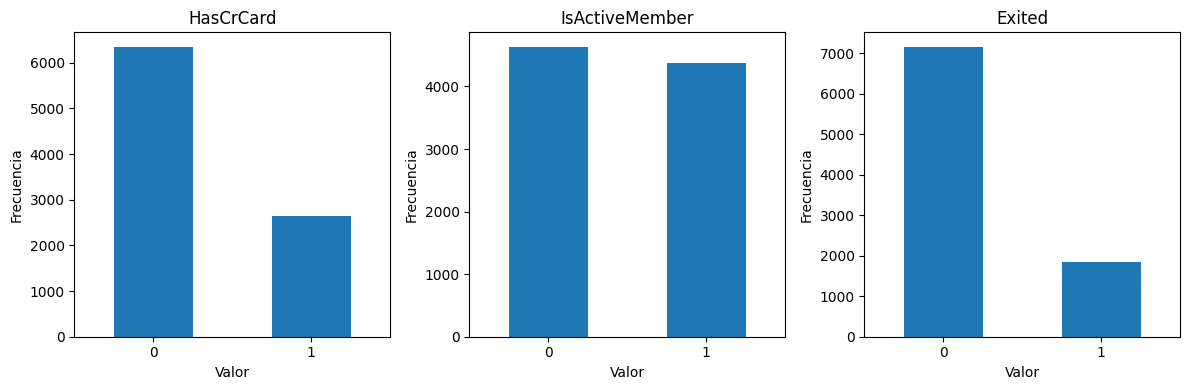

In [59]:
# review binary variables

binary = ['HasCrCard', 'IsActiveMember', 'Exited']

binary_df = df[binary]

binary_df.info()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(binary):
    binary_df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      9001 non-null   int64  
 1   Age              9000 non-null   float64
 2   Tenure           9001 non-null   int64  
 3   Balance          9001 non-null   float64
 4   EstimatedSalary  9001 non-null   float64
 5   NumOfProducts    9001 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 422.1 KB


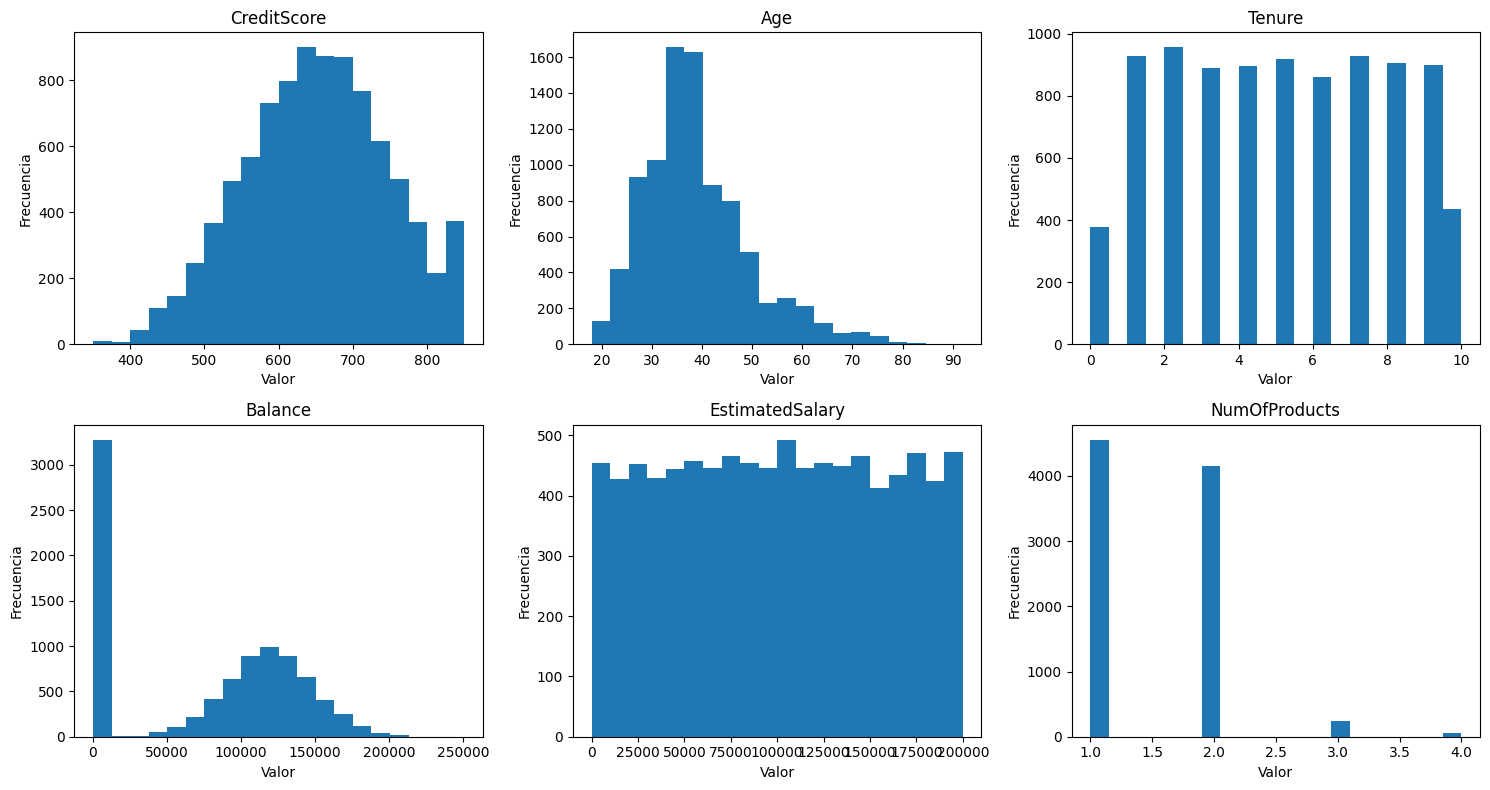

In [60]:
# review numerical variables

numerical = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'NumOfProducts']

numerical_df = df[numerical]

numerical_df.info()

plt.close('all')
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical):
    axes[i].hist(numerical_df[col].dropna(), bins=20)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**EDA Conclusions**

From this Exploratory Data Analysis we can retrieve the following information:

The dataset contains 12 variables with 9,001 entries. Three of those variables have a missing value in one of the entries. It is sufficient to remove those entries to treat the missing values.

There are 3 categorical variables. The distribution of the frequency of surnames is not uniform, it is concentrated among less than half of the distinct surnames. Half of the entries in Geography are concentrated in France, while the other half is split equally between Spain and Germany, giving France higher representation in the data. Gender is approximately equally represented, with slightly more entries being male than female.

In addition to Gender, there are 3 binary variables. Most entries do not have a credit card and have not exited. The number of entries for Active Members is roughly equally split, with slightly more entries belonging to non-active members.

For the numeric variables, Credit Score shows a near-Gaussian distribution with a slight left skew, centered between 600 and 700. Age shows a distribution with high contentration between 30 and 40 and a right skew with a long right tail, centered between 30 and 40. Tenure and Estimated Salary are uniformly distributed. Balance shows a bimodal distribution — one normal distribution centered between 100,000 and 150,000, and another concentrated near 0. Number of prdducts is heavily concentrated in 1 and 2.

In terms of treating outliers, for the CreditScore, the IQR method should be applied with values 0.1 and 0.9 given how it follows a gausean distribution with no clear outliers in the histogram other than a few on the right end making it so that this methos does not remove too many values. Age should be treated with a winsorize method at the 99th percentile to avoid removing too much information from the elder population. Treating outliers is unnecessary for Tenure and Estimated Salary given how they show an overall uniform distribution with no visible outliers. In Tenure specifically, those near 0 and 10 with lower frequency represent brand new customers and the longest tenured customers, that being valuable information.

For Balance, a new binary feature should be added, stating whether the entry has balance or not, given the high concentration of customers near 0.

Number of product entries with 3 and 4 should not be removed to prevent the model from being biased into the common situation.

Row Number, customer Id and surname should be dropped to prevent them from adding noice to the model, given how they don't add anything to the analysis.

### ML Pipeline

In this section the students are required to create a ML pipeline to predict whether the customer left the bank or not.

In [61]:
# import packages
import pandas as pd

In [62]:
# Load the dataset

df = pd.read_csv("Churn_Modelling_train_test.csv")

In [71]:
# Preprocess the features - create a function or a class for it 

#One-hot encoding of categorical variables
ONE_HOT_ENCODE_COLUMNS = [
                'Geography',
                'Gender',
            ]

encoder = OneHotEncoder(drop='first', sparse_output=False).set_output(transform="pandas")

def transform(df: pd.DataFrame) -> pd.DataFrame:
    #Dropping irrelevant columns and adding new columns
    df2 = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
    df2['HasBalance'] = (df2['Balance'] > 0).astype(int)
    #Remove null
    df_no_null = df2.dropna()

    print(df_no_null.isnull().sum())

    #Treating outliers

    df_no_outliers = df_no_null.copy()

    #Winsorize Age at 99th percentile
    age_cap = df2['Age'].quantile(0.99)
    df_no_outliers['Age'] = df_no_outliers['Age'].clip(upper=age_cap)

    print(df_no_outliers.isnull().sum())

    #IQR in CreditScore
    Q1 = df_no_outliers['CreditScore'].quantile(0.10)
    Q3 = df_no_outliers['CreditScore'].quantile(0.90)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_no_outliers['CreditScore'] = df_no_outliers['CreditScore'].clip(lower=lower_bound, upper=upper_bound)

    print(df_no_outliers.isnull().sum())

    #One-hot encoding of categorical variables
    encoder.fit(df_no_outliers[ONE_HOT_ENCODE_COLUMNS])
    encoded_df = encoder.transform(df_no_outliers[ONE_HOT_ENCODE_COLUMNS])
    df_no_outliers = df_no_outliers.drop(columns=ONE_HOT_ENCODE_COLUMNS)
    df_no_outliers = pd.concat([df_no_outliers, encoded_df], axis=1)

    print(df_no_outliers.isnull().sum())

    return df_no_outliers

# save encoder - future use

processed_df = transform(df)

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
HasBalance         0
dtype: int64
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
HasBalance         0
dtype: int64
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
HasBalance         0
dtype: int64
CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               

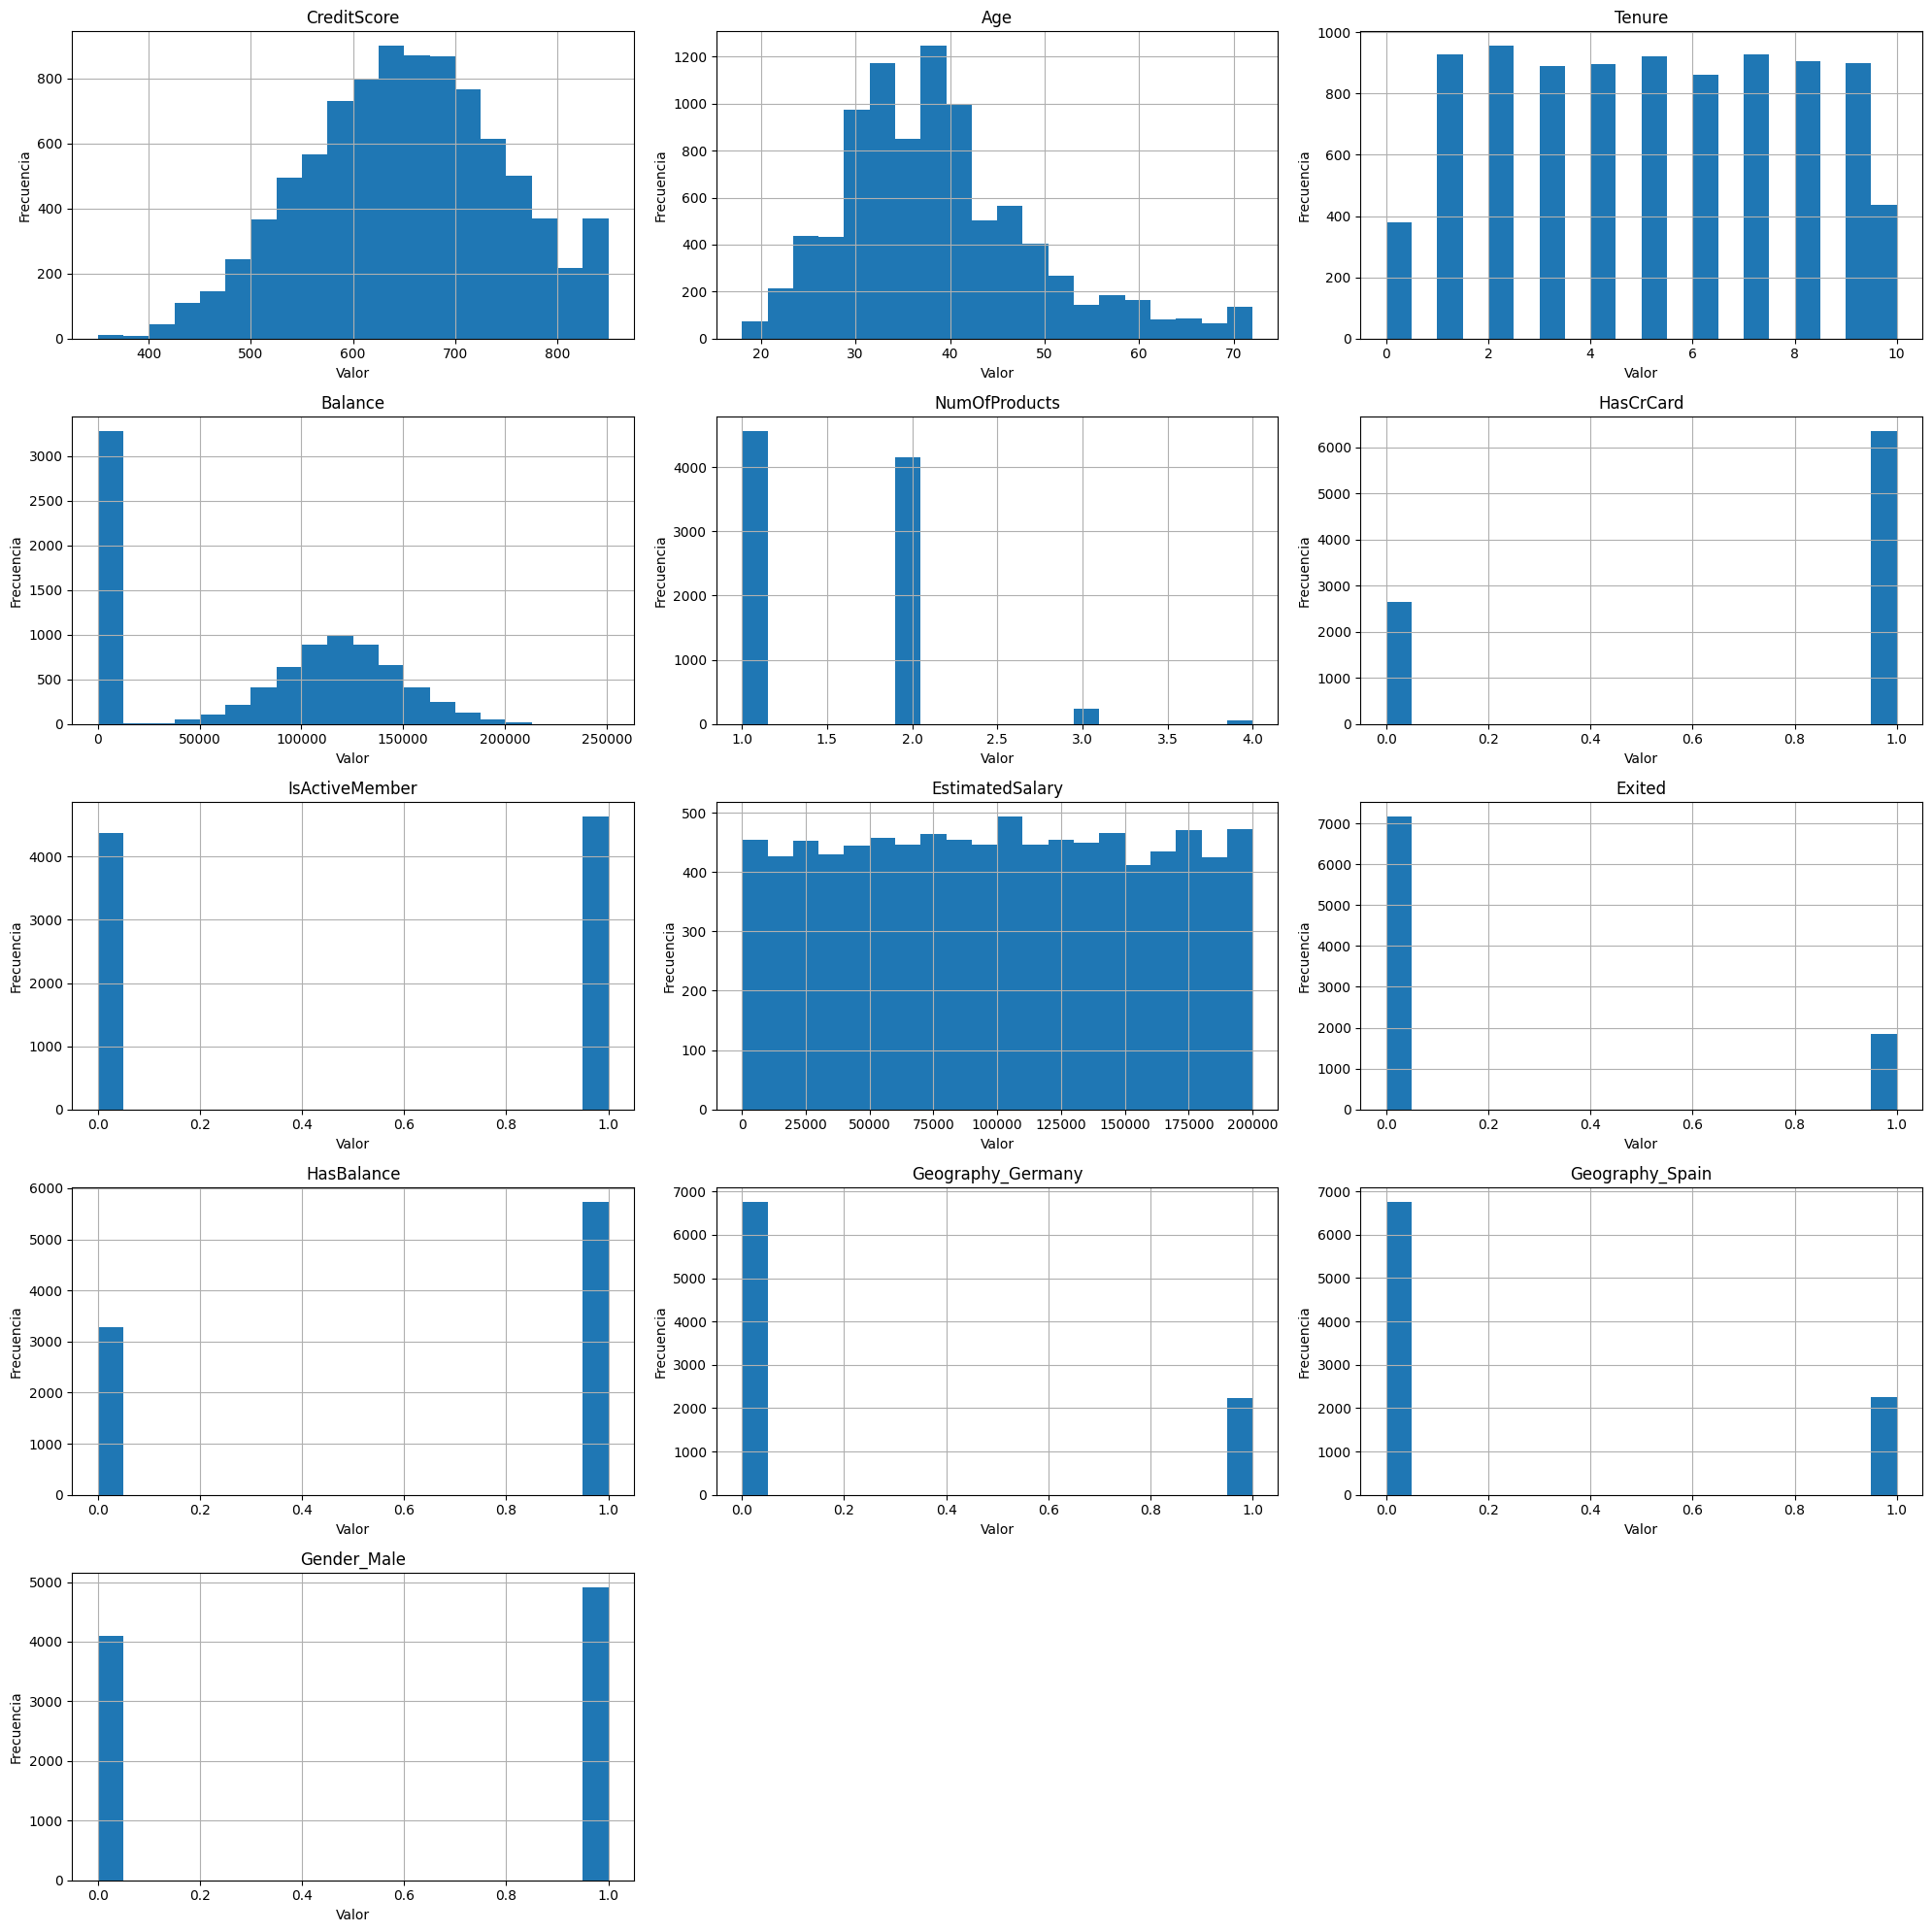

In [72]:
#Visualising distributions again after preprocessing

import math

#Organizing table dimensions for matplotlib visualization
cols = processed_df.columns.tolist()
n_cols = 3 #5 columns
n_rows = math.ceil(len(cols) / n_cols) #Number of row is number of variables divided by number of columns


fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    processed_df[col].hist(bins=20, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# balance the dataset (if you think it is necessary)
...

In [100]:
#Split the dataset into train and test sets

X = processed_df.drop('Exited', axis=1)
y = processed_df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [157]:
# Define the model hyperparameters
params = {
    "max_depth": 6,
    "min_samples_split": 9,
    "min_samples_leaf": 3,
    "class_weight": "balanced",  # to handle exited imbalance
    "random_state": 42
}

In [158]:
# Train a decision tree model using the `train sample`

from sklearn.tree import DecisionTreeClassifier

tr = DecisionTreeClassifier(**params)
tr.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, min_samples_leaf=3,
                       min_samples_split=9, random_state=42)

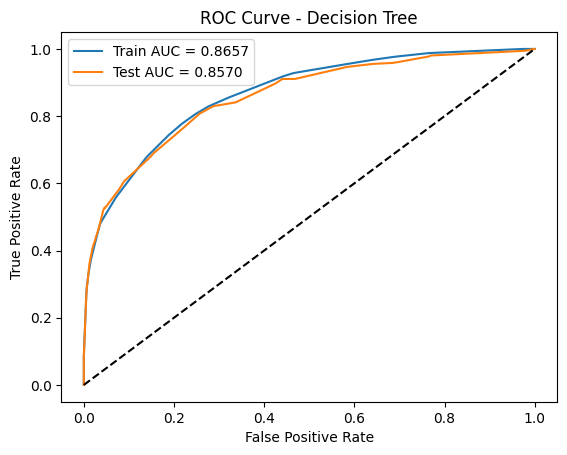

TRAIN:
               precision    recall  f1-score   support

           0       0.93      0.78      0.85      5716
           1       0.48      0.78      0.59      1482

    accuracy                           0.78      7198
   macro avg       0.71      0.78      0.72      7198
weighted avg       0.84      0.78      0.80      7198

TEST:
               precision    recall  f1-score   support

           0       0.93      0.77      0.85      1442
           1       0.46      0.77      0.57       358

    accuracy                           0.77      1800
   macro avg       0.70      0.77      0.71      1800
weighted avg       0.84      0.77      0.79      1800



In [159]:
# Check the accuracy of the model on the `test sample`

# Predict on BOTH sets tto identify overfitting and underfitting
y_pred_train = tr.predict(X_train)
y_prob_train = tr.predict_proba(X_train)[:, 1]

y_pred_test = tr.predict(X_test)
y_prob_test = tr.predict_proba(X_test)[:, 1]

# AUC for both
auc_train = roc_auc_score(y_train, y_prob_train)
auc_test = roc_auc_score(y_test, y_prob_test)

# ROC Curve for both
fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)

plt.plot(fpr_train, tpr_train, label=f'Train AUC = {auc_train:.4f}')
plt.plot(fpr_test, tpr_test, label=f'Test AUC = {auc_test:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()

# Classification reports
print("TRAIN:\n", classification_report(y_train, y_pred_train))
print("TEST:\n", classification_report(y_test, y_pred_test))

### MLFlow Integration

In this section the students are required to track the model and the parameters into MLFlow.

In [160]:
# import packages for mlfow
import mlflow
from mlflow.models import infer_signature

Start a local Tracking server on port 8080 - it is necessary to import mlflow and open a new terminal

In [162]:
# Set our tracking server uri for logging on port 8080
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

Visit the MLFlow UI on `http://127.0.0.1:8080`

In [ ]:
# Create a new MLflow Experiment called `Practice Experiment - {Your Name}`
...

In [ ]:
# Start an MLflow run
with mlflow.start_run():
    # Log the hyperparameters

    # Log the loss metric

    # Set a tag that we can use to remind ourselves what this run was for
    # Info about tags is pending

    # Infer the model signature

    # Log the model

### Keep practicing

In [3]:
# Create a new experiment using other models or different parameters
...